# Notebook 4: Visualisasi & Reporting — Gold Layer
## Proyek Analisis Performa Kampanye Marketing

**Penanggung Jawab:** Nikita Tsalis Akmalinda Yanisa (PM & Documentation)

### Medallion Architecture
- Input: `silver/marketing_campaign_features` dan `gold/predictions`
- Output: `gold/channel_performance_summary` dan `gold/campaign_profitability_report`

---
## Step 1: Setup & Load Data (Silver & Gold Layers)

In [1]:
import os, sys, warnings, glob as _glob
warnings.filterwarnings('ignore')

os.environ["JAVA_HOME"]   = r"C:\Program Files\Java\jdk-21.0.10"
os.environ["SPARK_HOME"]  = r"C:\spark\spark-4.1.1-bin-hadoop3"
os.environ["HADOOP_HOME"] = r"C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop"
_py4j = _glob.glob(os.path.join(os.environ["SPARK_HOME"], "python", "lib", "py4j-*.zip"))
sys.path.insert(0, os.path.join(os.environ["SPARK_HOME"], "python"))
if _py4j: sys.path.insert(0, _py4j[0])

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("[OK] Library berhasil di-import!")
print(f"   JAVA_HOME   : {os.environ['JAVA_HOME']}")
print(f"   SPARK_HOME  : {os.environ['SPARK_HOME']}")
print(f"   HADOOP_HOME : {os.environ['HADOOP_HOME']}")

[OK] Library berhasil di-import!
   JAVA_HOME   : C:\Program Files\Java\jdk-21.0.10
   SPARK_HOME  : C:\spark\spark-4.1.1-bin-hadoop3
   HADOOP_HOME : C:\Users\muham\OneDrive\Dokumen\Dokumen\BigData\bigdata6-marketing-analytics\hadoop


In [2]:
MINIO_ENDPOINT = "localhost:9000"
MINIO_ACCESS_KEY = "minioadmin"
MINIO_SECRET_KEY = "minioadmin123"
MINIO_BUCKET = "marketing-data"

GOLD_PREDICTIONS_PATH          = f"s3a://{MINIO_BUCKET}/gold/predictions"
GOLD_CHANNEL_SUMMARY_PATH      = f"s3a://{MINIO_BUCKET}/gold/channel_performance_summary"
GOLD_PROFITABILITY_REPORT_PATH = f"s3a://{MINIO_BUCKET}/gold/campaign_profitability_report"

spark = SparkSession.builder \
    .appName("Marketing_Visualization_Reporting") \
    .master("local[*]") \
    .config("spark.hadoop.fs.s3a.endpoint", f"http://{MINIO_ENDPOINT}") \
    .config("spark.hadoop.fs.s3a.access.key", MINIO_ACCESS_KEY) \
    .config("spark.hadoop.fs.s3a.secret.key", MINIO_SECRET_KEY) \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.threads.keepalivetime", "60") \
    .config("spark.hadoop.fs.s3a.connection.timeout", "200000") \
    .config("spark.hadoop.fs.s3a.connection.establish.timeout", "30000") \
    .config("spark.hadoop.fs.s3a.connection.ttl", "300000") \
    .config("spark.hadoop.fs.s3a.multipart.purge.age", "86400") \
    .config("spark.hadoop.fs.s3a.assumed.role.session.duration", "1800") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f'[OK] SparkSession dibuat! Versi: {spark.version}')

[OK] SparkSession dibuat! Versi: 4.1.1


In [3]:
df_predictions = spark.read.parquet(GOLD_PREDICTIONS_PATH)

# Gunakan Data Gold untuk keseluruhan analisis
pdf = df_predictions.toPandas()
pdf_pred = pdf.copy()

print(f'[OK] Data dimuat dari Gold Layer!')
print(f'   Predictions (Gold)  : {len(pdf_pred):,} baris')
print(f'   Kolom pred          : {list(pdf_pred.columns)}')

[OK] Data dimuat dari Gold Layer!
   Predictions (Gold)  : 10,000 baris
   Kolom pred          : ['CampaignID', 'Channel', 'is_profitable', 'rf_prediction', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue_USD', 'Cost_USD', 'ROI', 'CTR', 'CPC', 'CPL', 'CVR', 'Lead_Rate', 'ROAS', 'Profit_USD', 'Campaign_Duration', 'Start_Month', 'Start_DayOfWeek', 'lr_predicted_revenue']


---
## Step 2: Analisis Performa per Channel

=== Performa per Channel ===
   Channel  Jumlah_Kampanye  Avg_ROI  Total_Revenue  Avg_Revenue  Total_Cost  Avg_Conversions  Avg_CTR  Avg_CVR
    Search             1924    1.013     9897677.79     5144.323  4916568.46         1014.424    0.055    0.121
     Email             1996    1.010    10130542.61     5075.422  5065029.98         1040.292    0.055    0.121
   Display             2069    0.999    10715125.21     5178.891  5343184.30          994.493    0.054    0.121
Influencer             2056    0.998    10558118.99     5135.272  5278787.92         1021.983    0.055    0.120
    Social             1955    0.988     9725024.70     4974.437  4919999.25          982.107    0.054    0.121


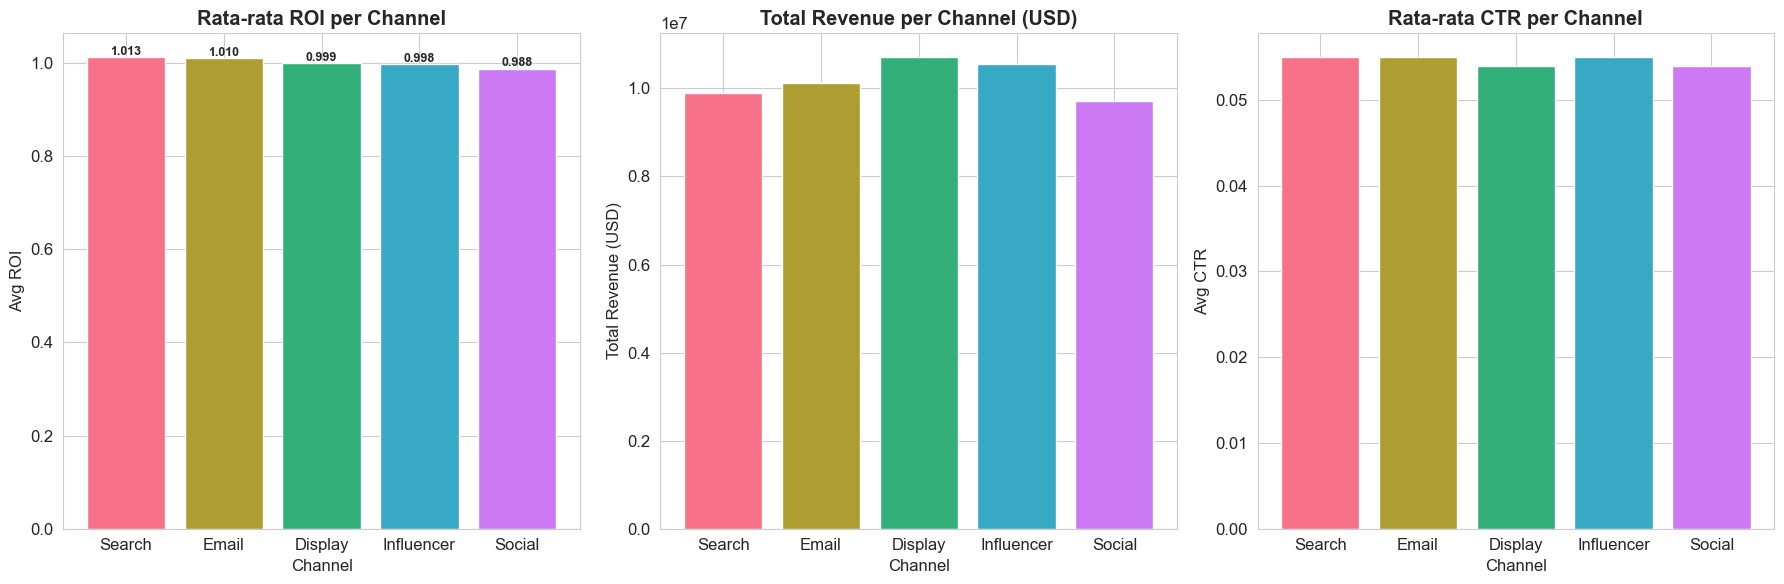

In [4]:
# Agregasi: ROI & Revenue per Channel
channel_agg = pdf.groupby('Channel').agg(
    Jumlah_Kampanye  = ('CampaignID',  'count'),
    Avg_ROI          = ('ROI',          'mean'),
    Total_Revenue    = ('Revenue_USD',  'sum'),
    Avg_Revenue      = ('Revenue_USD',  'mean'),
    Total_Cost       = ('Cost_USD',     'sum'),
    Avg_Conversions  = ('Conversions',  'mean'),
    Avg_CTR          = ('CTR',          'mean'),
    Avg_CVR          = ('CVR',          'mean'),
).reset_index().round(3)

channel_agg = channel_agg.sort_values('Avg_ROI', ascending=False)
print('=== Performa per Channel ===')
print(channel_agg.to_string(index=False))

colors = sns.color_palette('husl', len(channel_agg))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Avg ROI
axes[0].bar(channel_agg['Channel'], channel_agg['Avg_ROI'], color=colors)
axes[0].set_title('Rata-rata ROI per Channel', fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Avg ROI')
for i, v in enumerate(channel_agg['Avg_ROI']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Total Revenue
axes[1].bar(channel_agg['Channel'], channel_agg['Total_Revenue'], color=colors)
axes[1].set_title('Total Revenue per Channel (USD)', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Total Revenue (USD)')

# Avg CTR
axes[2].bar(channel_agg['Channel'], channel_agg['Avg_CTR'], color=colors)
axes[2].set_title('Rata-rata CTR per Channel', fontweight='bold')
axes[2].set_xlabel('Channel')
axes[2].set_ylabel('Avg CTR')

plt.tight_layout()
plt.show()

---
## Step 3: Analisis Profitabilitas Kampanye

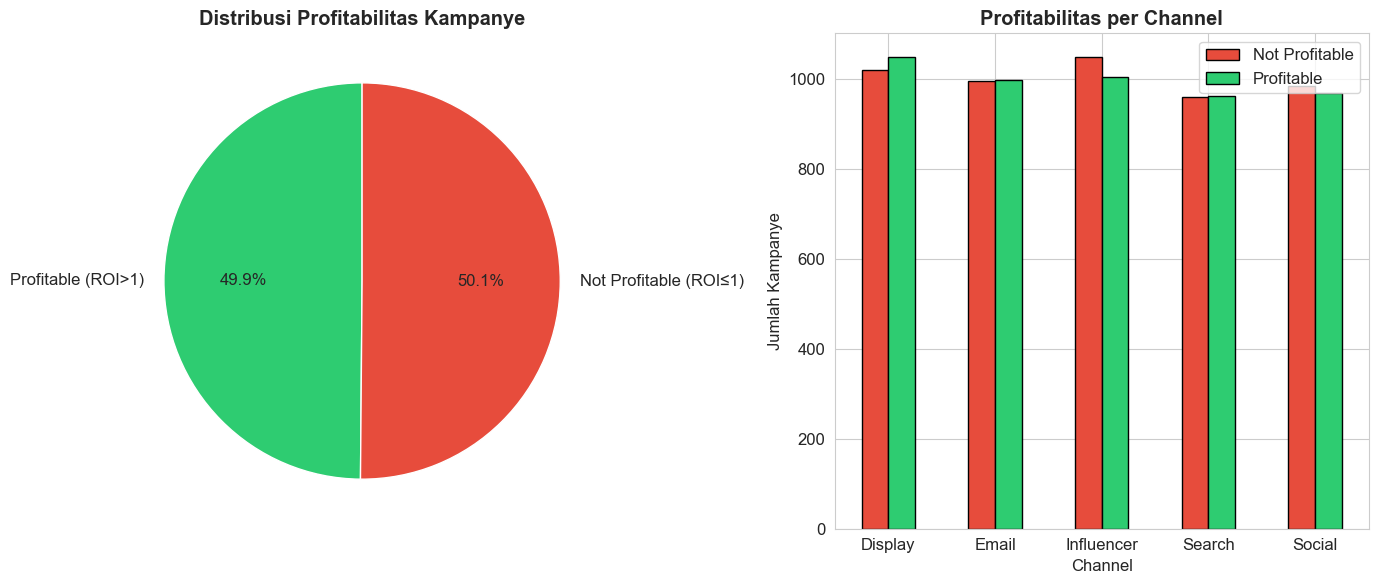

Total kampanye profitable     : 4,987 (49.9%)
Total kampanye not profitable : 5,013 (50.1%)


In [5]:
# Profitabilitas keseluruhan
profit_counts = pdf['is_profitable'].value_counts()
labels = ['Profitable (ROI>1)', 'Not Profitable (ROI≤1)']
values = [profit_counts.get(1, 0), profit_counts.get(0, 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie Chart
axes[0].pie(values, labels=labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribusi Profitabilitas Kampanye', fontweight='bold')

# Profitabilitas per Channel
profit_channel = pdf.groupby(['Channel', 'is_profitable']).size().unstack(fill_value=0)
profit_channel.columns = ['Not Profitable', 'Profitable']
profit_channel.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Profitabilitas per Channel', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Jumlah Kampanye')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Total kampanye profitable     : {values[0]:,} ({values[0]/sum(values)*100:.1f}%)')
print(f'Total kampanye not profitable : {values[1]:,} ({values[1]/sum(values)*100:.1f}%)')

---
## Step 4: Analisis Hasil Prediksi Model (Gold Predictions)

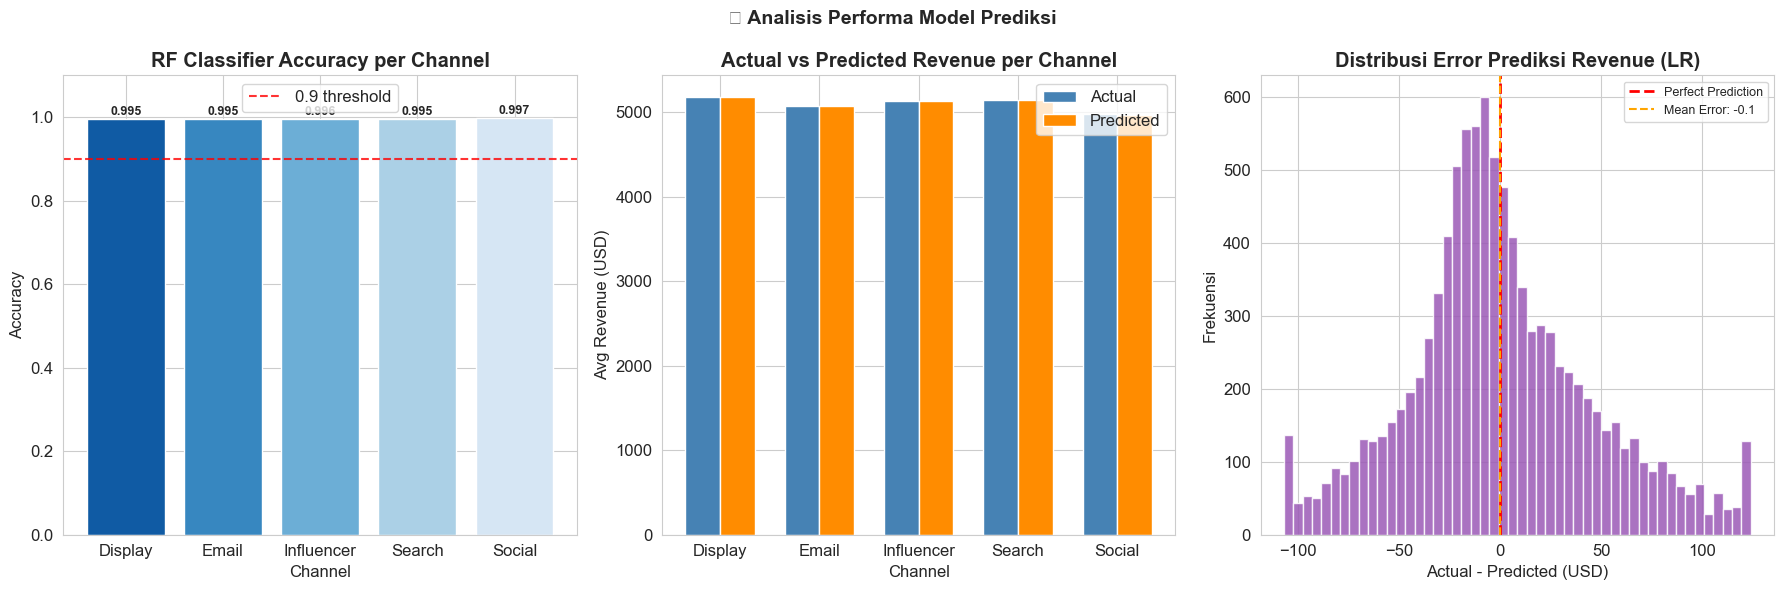

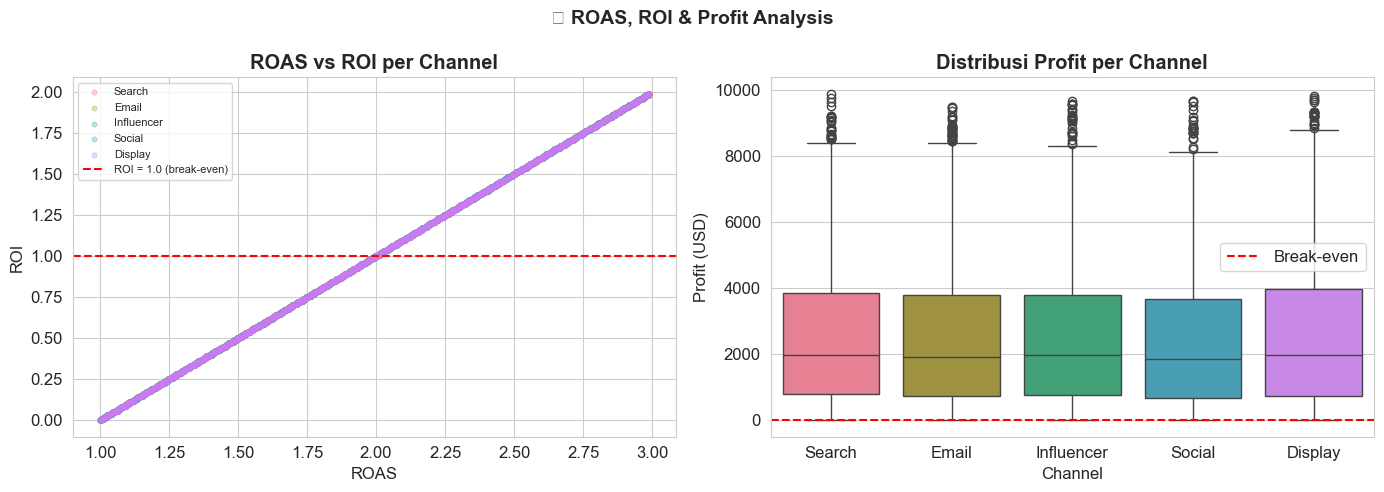

In [6]:
# Akurasi RF per channel
pdf_pred['rf_correct'] = (pdf_pred['rf_prediction'] == pdf_pred['is_profitable']).astype(int)
rf_acc_per_channel = pdf_pred.groupby('Channel')['rf_correct'].mean().reset_index()
rf_acc_per_channel.columns = ['Channel', 'RF_Accuracy']

# Revenue: Actual vs Predicted per channel
rev_per_channel = pdf_pred.groupby('Channel').agg(
    Actual_Revenue    = ('Revenue_USD', 'mean'),
    Predicted_Revenue = ('lr_predicted_revenue', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# RF Accuracy per Channel
colors_acc = sns.color_palette('Blues_r', len(rf_acc_per_channel))
bars = axes[0].bar(rf_acc_per_channel['Channel'], rf_acc_per_channel['RF_Accuracy'], color=colors_acc)
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.9, color='red', linestyle='--', alpha=0.8, label='0.9 threshold')
axes[0].set_title('RF Classifier Accuracy per Channel', fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
for i, v in enumerate(rf_acc_per_channel['RF_Accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# Actual vs Predicted Revenue per Channel
x = range(len(rev_per_channel))
w = 0.35
axes[1].bar([i - w/2 for i in x], rev_per_channel['Actual_Revenue'],    w, label='Actual',    color='steelblue',  edgecolor='white')
axes[1].bar([i + w/2 for i in x], rev_per_channel['Predicted_Revenue'], w, label='Predicted', color='darkorange', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(rev_per_channel['Channel'])
axes[1].set_title('Actual vs Predicted Revenue per Channel', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Avg Revenue (USD)')
axes[1].legend()

# Prediction Error Distribution (LR)
pdf_pred['lr_error'] = pdf_pred['Revenue_USD'] - pdf_pred['lr_predicted_revenue']
axes[2].hist(pdf_pred['lr_error'].clip(lower=pdf_pred['lr_error'].quantile(0.01),
                                        upper=pdf_pred['lr_error'].quantile(0.99)),
             bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
axes[2].axvline(x=pdf_pred['lr_error'].mean(), color='orange', linestyle='--',
                linewidth=1.5, label=f'Mean Error: {pdf_pred["lr_error"].mean():.1f}')
axes[2].set_title('Distribusi Error Prediksi Revenue (LR)', fontweight='bold')
axes[2].set_xlabel('Actual - Predicted (USD)')
axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=9)

plt.suptitle('📊 Analisis Performa Model Prediksi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── ROAS Distribution per channel ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
channels_sorted = pdf_pred['Channel'].unique()
colors_ch = sns.color_palette('husl', len(channels_sorted))

for ch, c in zip(channels_sorted, colors_ch):
    sub = pdf_pred[pdf_pred['Channel'] == ch]
    axes[0].scatter(sub['ROAS'].clip(upper=sub['ROAS'].quantile(0.99)),
                    sub['ROI'].clip(upper=sub['ROI'].quantile(0.99)),
                    alpha=0.3, label=ch, s=12, color=c)
axes[0].axhline(y=1.0, color='red', linestyle='--', linewidth=1.5, label='ROI = 1.0 (break-even)')
axes[0].set_title('ROAS vs ROI per Channel', fontweight='bold')
axes[0].set_xlabel('ROAS')
axes[0].set_ylabel('ROI')
axes[0].legend(fontsize=8)

# Profit distribution per channel
sns.boxplot(data=pdf_pred, x='Channel', y='Profit_USD',
            palette='husl', ax=axes[1],
            order=channels_sorted)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
axes[1].set_title('Distribusi Profit per Channel', fontweight='bold')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Profit (USD)')
axes[1].legend()

plt.suptitle('💰 ROAS, ROI & Profit Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5: KPI Dashboard & Business Insights

     MARKETING CAMPAIGN PERFORMANCE DASHBOARD
  Total Kampanye        :     10,000
  Total Revenue (USD)   : 51,026,489.30
  Total Cost (USD)      : 25,523,569.91
  Total Profit (USD)    : 25,502,919.39
  Overall ROI (avg)     :     1.0016
  Overall ROAS (avg)    :     2.0015
  Profitability Rate    :      49.9%
  Avg CTR               :   0.054622
  Avg CVR               :   0.120940

  Best Channel (by ROI) : Search
  → Avg ROI             : 1.0130
  → Total Revenue       : $9,897,677.79

  RF Classifier Accuracy (Overall) : 0.9957 (99.6%)
  LR Mean Absolute Error           : $35.85


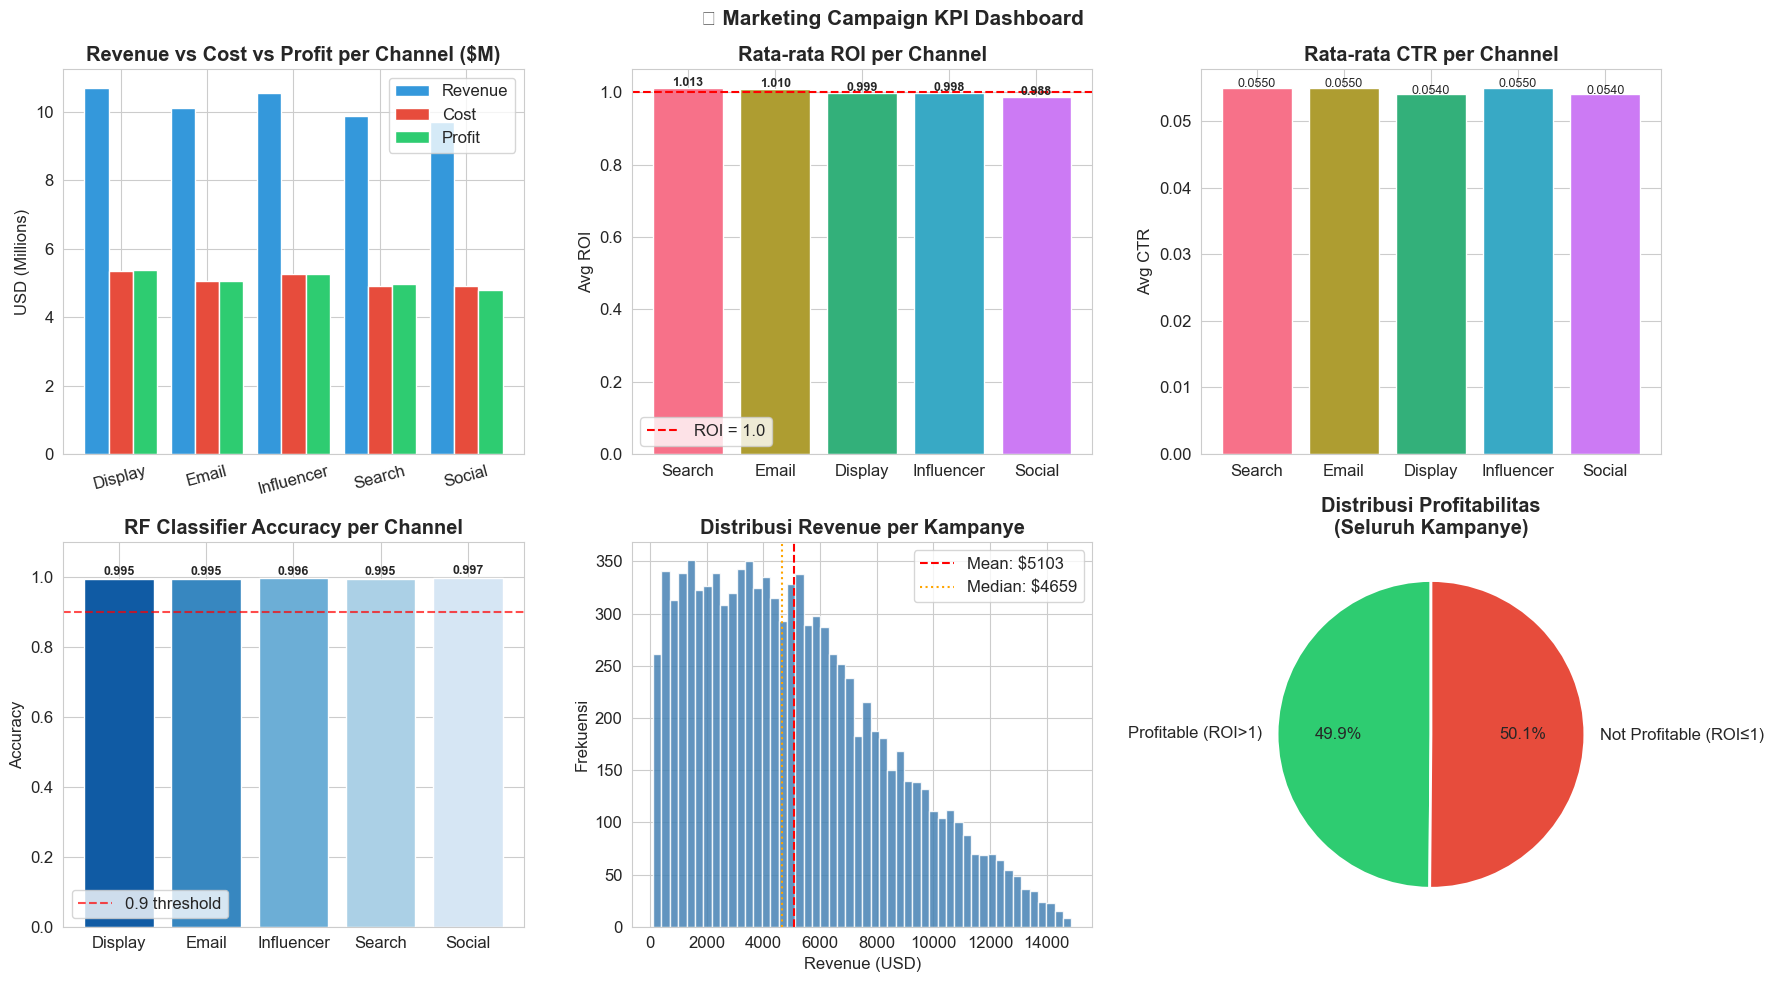

In [7]:
total_revenue   = pdf['Revenue_USD'].sum()
total_cost      = pdf['Cost_USD'].sum()
overall_roi     = pdf['ROI'].mean()
profit_rate     = pdf['is_profitable'].mean() * 100
total_campaigns = len(pdf)
avg_ctr         = pdf['CTR'].mean()
avg_cvr         = pdf['CVR'].mean()
avg_roas        = pdf['ROAS'].mean()
total_profit    = pdf['Profit_USD'].sum()

print('='*60)
print('     MARKETING CAMPAIGN PERFORMANCE DASHBOARD')
print('='*60)
print(f'  Total Kampanye        : {total_campaigns:>10,}')
print(f'  Total Revenue (USD)   : {total_revenue:>10,.2f}')
print(f'  Total Cost (USD)      : {total_cost:>10,.2f}')
print(f'  Total Profit (USD)    : {total_profit:>10,.2f}')
print(f'  Overall ROI (avg)     : {overall_roi:>10.4f}')
print(f'  Overall ROAS (avg)    : {avg_roas:>10.4f}')
print(f'  Profitability Rate    : {profit_rate:>9.1f}%')
print(f'  Avg CTR               : {avg_ctr:>10.6f}')
print(f'  Avg CVR               : {avg_cvr:>10.6f}')
print('='*60)

best_channel = channel_agg.iloc[0]['Channel']
print(f'\n  Best Channel (by ROI) : {best_channel}')
print(f'  → Avg ROI             : {channel_agg.iloc[0]["Avg_ROI"]:.4f}')
print(f'  → Total Revenue       : ${channel_agg.iloc[0]["Total_Revenue"]:,.2f}')

# Cek kualitas prediksi model
overall_rf_acc = pdf_pred['rf_correct'].mean()
lr_mae_val = pdf_pred['lr_error'].abs().mean()
print(f'\n  RF Classifier Accuracy (Overall) : {overall_rf_acc:.4f} ({overall_rf_acc*100:.1f}%)')
print(f'  LR Mean Absolute Error           : ${lr_mae_val:,.2f}')

# ── KPI Visual Dashboard ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Revenue vs Cost vs Profit per Channel
ch_fin = pdf.groupby('Channel').agg(
    Revenue=('Revenue_USD','sum'), Cost=('Cost_USD','sum'), Profit=('Profit_USD','sum')
).reset_index()
x = np.arange(len(ch_fin)); w = 0.28
axes[0,0].bar(x - w, ch_fin['Revenue']/1e6, w, label='Revenue', color='#3498db', edgecolor='white')
axes[0,0].bar(x,     ch_fin['Cost']/1e6,    w, label='Cost',    color='#e74c3c', edgecolor='white')
axes[0,0].bar(x + w, ch_fin['Profit']/1e6,  w, label='Profit',  color='#2ecc71', edgecolor='white')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(ch_fin['Channel'], rotation=15)
axes[0,0].set_title('Revenue vs Cost vs Profit per Channel ($M)', fontweight='bold')
axes[0,0].set_ylabel('USD (Millions)'); axes[0,0].legend()

# 2. Avg ROI per Channel
colors_bar = sns.color_palette('husl', len(channel_agg))
bars = axes[0,1].bar(channel_agg['Channel'], channel_agg['Avg_ROI'], color=colors_bar, edgecolor='white')
axes[0,1].axhline(y=1.0, color='red', linestyle='--', label='ROI = 1.0')
axes[0,1].set_title('Rata-rata ROI per Channel', fontweight='bold')
axes[0,1].set_ylabel('Avg ROI'); axes[0,1].legend()
for i, v in enumerate(channel_agg['Avg_ROI']):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# 3. Avg CTR per Channel
axes[0,2].bar(channel_agg['Channel'], channel_agg['Avg_CTR'], color=colors_bar, edgecolor='white')
axes[0,2].set_title('Rata-rata CTR per Channel', fontweight='bold')
axes[0,2].set_ylabel('Avg CTR')
for i, v in enumerate(channel_agg['Avg_CTR']):
    axes[0,2].text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=9)

# 4. RF Accuracy per Channel
axes[1,0].bar(rf_acc_per_channel['Channel'], rf_acc_per_channel['RF_Accuracy'],
              color=sns.color_palette('Blues_r', len(rf_acc_per_channel)), edgecolor='white')
axes[1,0].set_ylim(0, 1.1)
axes[1,0].axhline(y=0.9, color='red', linestyle='--', alpha=0.7, label='0.9 threshold')
axes[1,0].set_title('RF Classifier Accuracy per Channel', fontweight='bold')
axes[1,0].set_ylabel('Accuracy'); axes[1,0].legend()
for i, v in enumerate(rf_acc_per_channel['RF_Accuracy']):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

# 5. Revenue Distribution
axes[1,1].hist(pdf['Revenue_USD'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1,1].axvline(pdf['Revenue_USD'].mean(), color='red', linestyle='--',
                  label=f'Mean: ${pdf["Revenue_USD"].mean():.0f}')
axes[1,1].axvline(pdf['Revenue_USD'].median(), color='orange', linestyle=':',
                  label=f'Median: ${pdf["Revenue_USD"].median():.0f}')
axes[1,1].set_title('Distribusi Revenue per Kampanye', fontweight='bold')
axes[1,1].set_xlabel('Revenue (USD)'); axes[1,1].set_ylabel('Frekuensi'); axes[1,1].legend()

# 6. Profitability pie
axes[1,2].pie(values, labels=labels, autopct='%1.1f%%',
              colors=['#2ecc71', '#e74c3c'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,2].set_title('Distribusi Profitabilitas\n(Seluruh Kampanye)', fontweight='bold')

plt.suptitle('📊 Marketing Campaign KPI Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

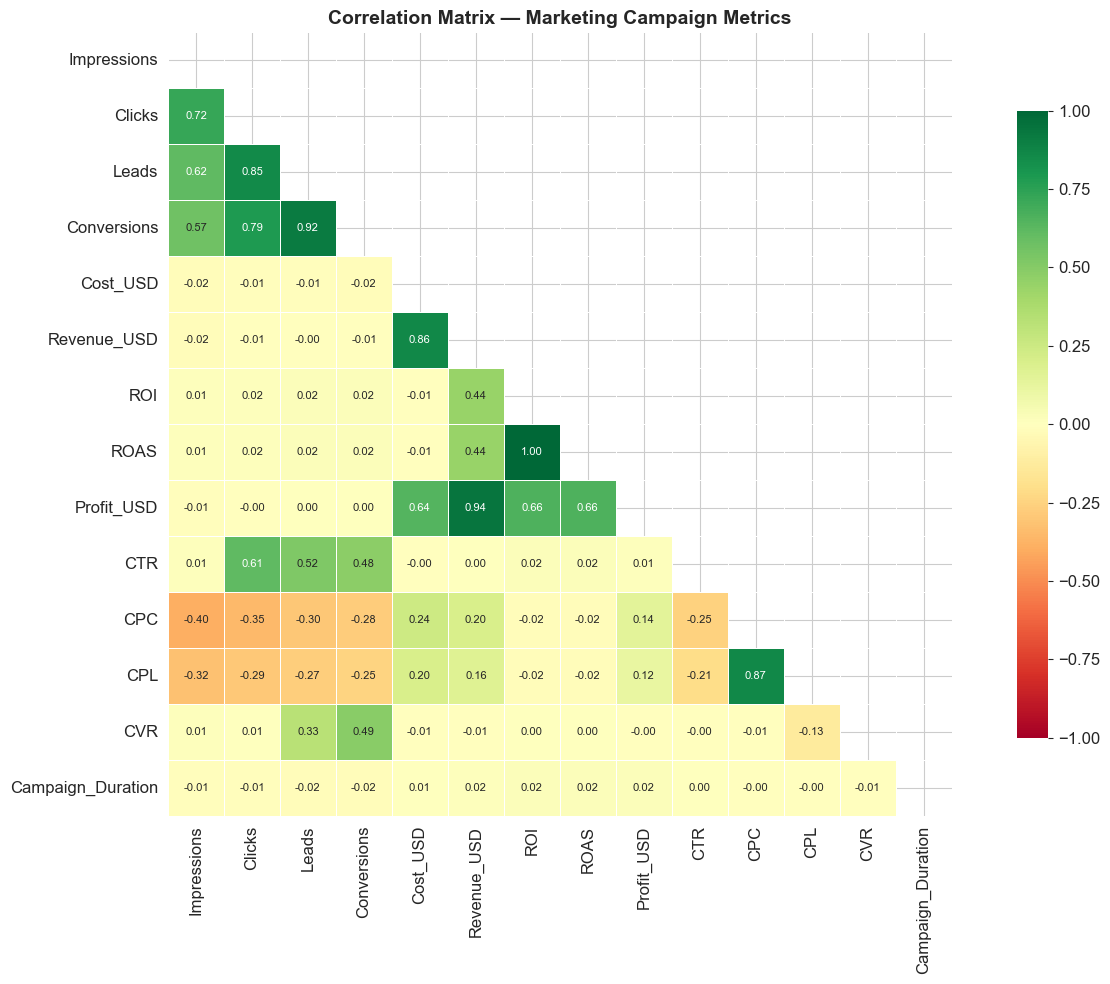

In [8]:
# Heatmap Korelasi antar Metrik
corr_cols = ['Impressions','Clicks','Leads','Conversions','Cost_USD','Revenue_USD',
             'ROI','ROAS','Profit_USD','CTR','CPC','CPL','CVR','Campaign_Duration']
corr_matrix = pdf[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Marketing Campaign Metrics', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

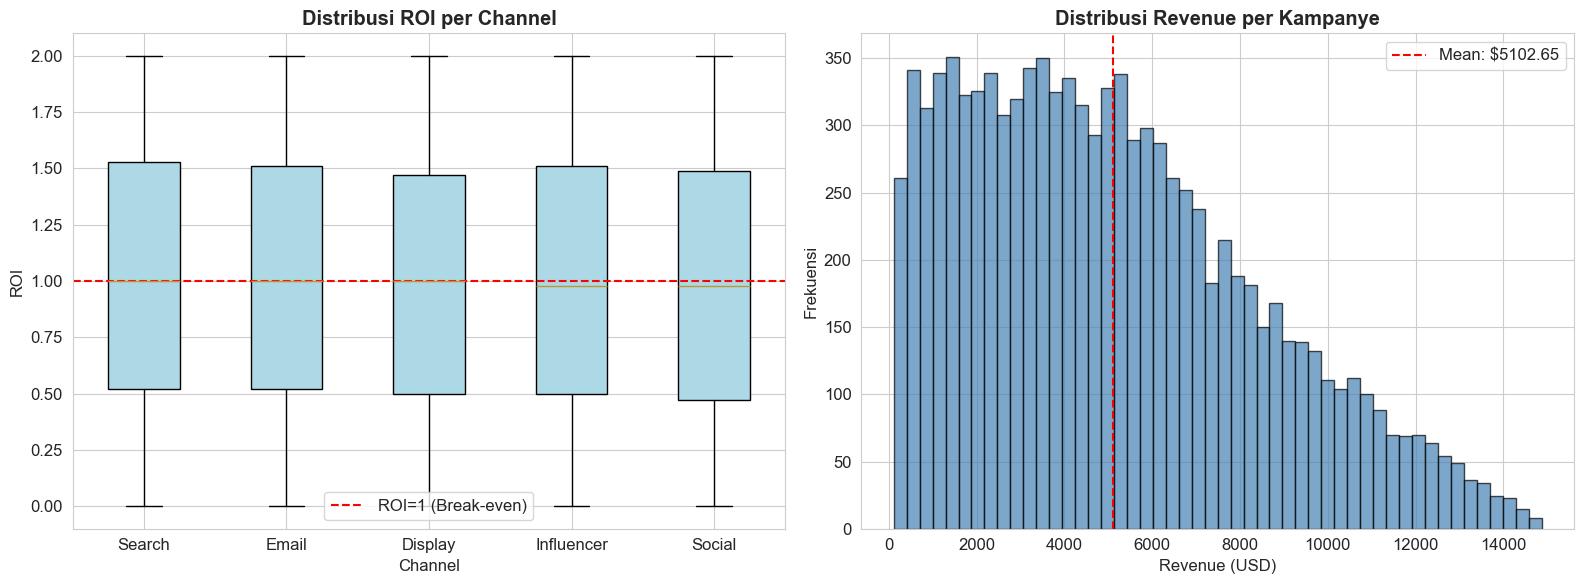

In [9]:
# Distribusi ROI per Channel (Box Plot)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

channels_sorted = channel_agg['Channel'].tolist()
data_by_channel = [pdf[pdf['Channel'] == ch]['ROI'].values for ch in channels_sorted]

axes[0].boxplot(data_by_channel, labels=channels_sorted, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[0].set_title('Distribusi ROI per Channel', fontweight='bold')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('ROI')
axes[0].axhline(y=1.0, color='red', linestyle='--', label='ROI=1 (Break-even)')
axes[0].legend()

# Revenue Distribution
axes[1].hist(pdf['Revenue_USD'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribusi Revenue per Kampanye', fontweight='bold')
axes[1].set_xlabel('Revenue (USD)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(pdf['Revenue_USD'].mean(), color='red', linestyle='--',
                label=f'Mean: ${pdf["Revenue_USD"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## Step 6: Simpan Aggregasi ke Gold Layer (MinIO)

In [10]:
# --- Gold: Channel Performance Summary ---
df_channel_summary = df_predictions.groupBy('Channel').agg(
    F.count('*').alias('Jumlah_Kampanye'),
    F.round(F.avg('ROI'), 4).alias('Avg_ROI'),
    F.round(F.avg('Revenue_USD'), 2).alias('Avg_Revenue'),
    F.round(F.sum('Revenue_USD'), 2).alias('Total_Revenue'),
    F.round(F.avg('Cost_USD'), 2).alias('Avg_Cost'),
    F.round(F.avg('Conversions'), 2).alias('Avg_Conversions'),
    F.round(F.avg('CTR'), 4).alias('Avg_CTR'),
    F.round(F.avg('CVR'), 4).alias('Avg_CVR')
).orderBy('Avg_ROI', ascending=False)

df_channel_summary.write.mode('overwrite').parquet(GOLD_CHANNEL_SUMMARY_PATH)
print(f'[OK] Gold Channel Summary disimpan: {GOLD_CHANNEL_SUMMARY_PATH}')
df_channel_summary.show()

# --- Gold: Campaign Profitability Report ---
df_profit_report = df_predictions.groupBy('Channel', 'is_profitable').agg(
    F.count('*').alias('Jumlah'),
    F.round(F.avg('ROI'), 4).alias('Avg_ROI'),
    F.round(F.sum('Revenue_USD'), 2).alias('Total_Revenue'),
    F.round(F.avg('Cost_USD'), 2).alias('Avg_Cost')
).orderBy('Channel', 'is_profitable')

df_profit_report.write.mode('overwrite').parquet(GOLD_PROFITABILITY_REPORT_PATH)
print(f'[OK] Gold Profitability Report disimpan: {GOLD_PROFITABILITY_REPORT_PATH}')
df_profit_report.show()

[OK] Gold Channel Summary disimpan: s3a://marketing-data/gold/channel_performance_summary
+----------+---------------+-------+-----------+-------------+--------+---------------+-------+-------+
|   Channel|Jumlah_Kampanye|Avg_ROI|Avg_Revenue|Total_Revenue|Avg_Cost|Avg_Conversions|Avg_CTR|Avg_CVR|
+----------+---------------+-------+-----------+-------------+--------+---------------+-------+-------+
|    Search|           1924| 1.0134|    5144.32|   9897677.79| 2555.39|        1014.42| 0.0552| 0.1211|
|     Email|           1996|   1.01|    5075.42|1.013054261E7| 2537.59|        1040.29| 0.0546| 0.1212|
|   Display|           2069| 0.9993|    5178.89|1.071512521E7|  2582.5|         994.49| 0.0543| 0.1211|
|Influencer|           2056| 0.9975|    5135.27|1.055811899E7|  2567.5|        1021.98| 0.0547| 0.1199|
|    Social|           1955|  0.988|    4974.44|    9725024.7| 2516.62|         982.11| 0.0544| 0.1214|
+----------+---------------+-------+-----------+-------------+--------+-------

In [ ]:
spark.stop()
print('[OK] SparkSession dihentikan')
print('[OK] Gold Layer selesai dibuat! Semua output tersimpan di MinIO.')